In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")  # use actual filename

/tmp/ipykernel_9982/3279050828.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  trades = pd.read_csv("historical_data.csv")


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,5.201771e+10,True,0.003055,1.050000e+15,1.730000e+12


In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trades.columns.tolist()

['Account',
 'Coin',
 'Execution Price',
 'Size Tokens',
 'Size USD',
 'Side',
 'Timestamp IST',
 'Start Position',
 'Direction',
 'Closed PnL',
 'Transaction Hash',
 'Order ID',
 'Crossed',
 'Fee',
 'Trade ID',
 'Timestamp']

In [8]:
sentiment.columns.tolist()

['timestamp', 'value', 'classification', 'date']

In [9]:
trades['Timestamp IST'].head(10)

,Timestamp IST
0,02-12-2024 22:50
1,02-12-2024 22:50
2,02-12-2024 22:50
3,02-12-2024 22:50
4,02-12-2024 22:50
5,02-12-2024 22:50
6,02-12-2024 22:50
7,02-12-2024 22:50
8,02-12-2024 22:50
9,02-12-2024 22:50


In [10]:
trades[['Timestamp IST', 'Timestamp']].head(10)

,Timestamp IST,Timestamp
0,02-12-2024 22:50,1.730000e+12
1,02-12-2024 22:50,1.730000e+12
2,02-12-2024 22:50,1.730000e+12
3,02-12-2024 22:50,1.730000e+12
4,02-12-2024 22:50,1.730000e+12
5,02-12-2024 22:50,1.730000e+12
6,02-12-2024 22:50,1.730000e+12
7,02-12-2024 22:50,1.730000e+12
8,02-12-2024 22:50,1.730000e+12
9,02-12-2024 22:50,1.730000e+12


In [11]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['trade_date'] = trades['Timestamp IST'].dt.normalize()

sentiment['date'] = pd.to_datetime(sentiment['date'])

In [12]:
trades[['Timestamp IST', 'trade_date']].head()

,Timestamp IST,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [13]:
merged = trades.merge(
    sentiment,
    left_on='trade_date',
    right_on='date',
    how='left'
)

print(merged.shape)

(37109, 21)


In [14]:
print(trades.shape)
print(sentiment.shape)

(37109, 17)
(2644, 4)


In [15]:
len(trades)

37109

In [16]:
merged['classification'].value_counts()

,count
classification,
Fear,10909
Greed,9944
Extreme Greed,7957
Neutral,6789
Extreme Fear,1504


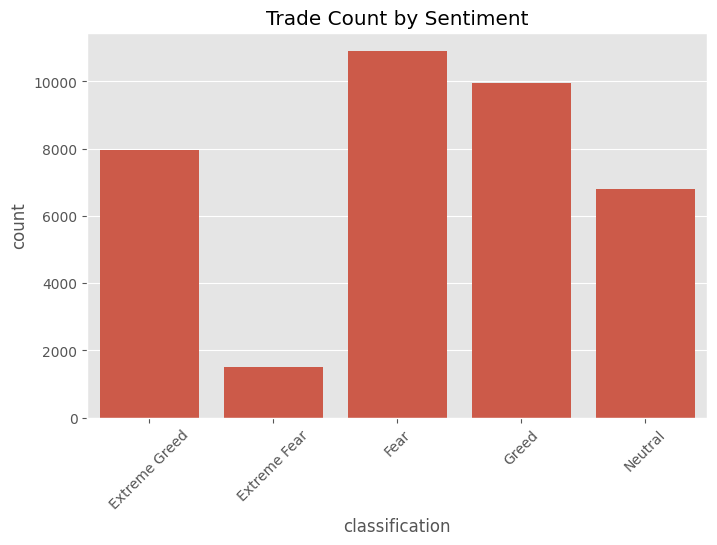

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=merged, x='classification')
plt.xticks(rotation=45)
plt.title("Trade Count by Sentiment")
plt.show()

In [18]:
merged.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

,Closed PnL
classification,
Extreme Fear,229.934580
Fear,151.441954
Greed,95.152662
Neutral,90.220750
Extreme Greed,55.983156


In [19]:
merged['win_trade'] = (merged['Closed PnL'] > 0).astype(int)

In [21]:
winrate = merged.groupby('classification')['win_trade'].mean()

winrate = winrate * 100

winrate = winrate.sort_values(ascending=False)

print(winrate)

classification
Extreme Greed    53.738846
Neutral          48.902637
Greed            46.027755
Fear             44.147035
Extreme Fear     43.284574
Name: win_trade, dtype: float64


In [22]:
merged.groupby('classification')['Size USD'].mean().sort_values(ascending=False)

,Size USD
classification,
Fear,25428.266009
Greed,18218.209690
Neutral,15997.242570
Extreme Fear,11143.684122
Extreme Greed,8995.327006


In [23]:
merged.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

,Closed PnL
classification,
Fear,1.652080e+06
Greed,9.461981e+05
Neutral,6.125087e+05
Extreme Greed,4.454580e+05
Extreme Fear,3.458216e+05


In [24]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

print(top_traders)

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.419977e+05
0x4f93fead39b70a1824f981a54d4e55b278e9f760    3.089759e+05
0xae5eacaf9c6b9111fd53034a602c192a04e082ed    6.784562e+04
0x8381e6d82f1affd39a336e143e081ef7620a3b7f    6.551366e+04
Name: Closed PnL, dtype: float64


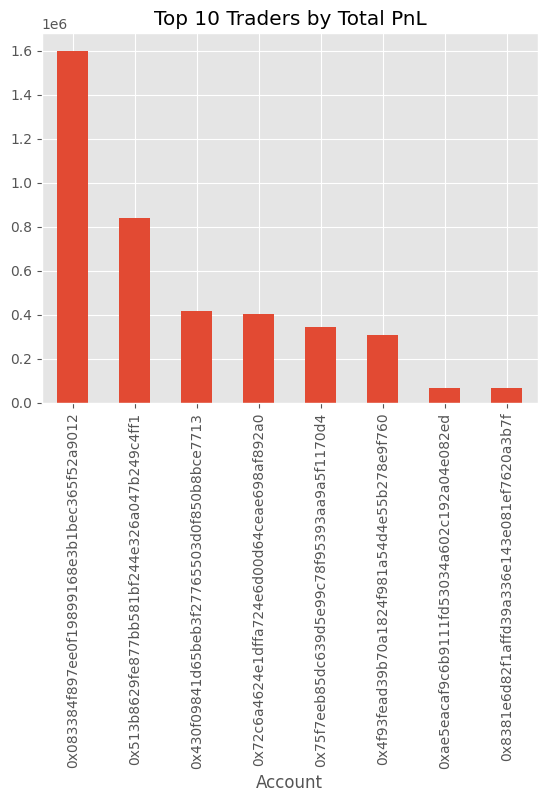

In [25]:
top_traders.plot(kind='bar')
plt.title('Top 10 Traders by Total PnL')
plt.show()

In [26]:
merged.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

,Closed PnL
classification,
Fear,1.652080e+06
Greed,9.461981e+05
Neutral,6.125087e+05
Extreme Greed,4.454580e+05
Extreme Fear,3.458216e+05
